# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sci
from scipy.integrate import quad
G = 6.67*10**11
g = 9.81
ME = 5.9*10**24
dist_E_M_2= 1.5*3.8*10**8
RE = 6378
MM = 7.3*10**22
DEM = 3.8*10**8
MA = 5500
BR = 1.3*10**4
WM_S1C = 2.8*10**6
DM_S1C = 7.5*10**5
EV = 2.4*10**3

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def GP(ME:float, xM:float, yM:float, x:np.ndarray, y:np.ndarray) -> np.ndarray:
    """
    This formula will give the gravitational potential at a distance r from a mass ME
    Args:
        ME: Mass(kg).
        xM: X-coordinate of the mass (m).
        yM: Y-coordinate of the mass (m).
        x: Evaluation point of x-coordinate(m).
        y: Evaluation point of y-coordinates(m).
    Returns:
        np.ndarray: The gravitational potential Phi(r) at each point.   
    """
    if ME <= 0:
        raise ValueError("Mass ME must be positive.")
    r = np.sqrt((xM-x)**2+(yM-y)**2)
    if np.any(r < 1e-7):
        raise ValueError("Error! Singlarity! One or more evaluation points are at the mass location.")
    phi = (-G*ME)/r
    assert np.all(phi < 0), "Values must be negative."

    return phi
    

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

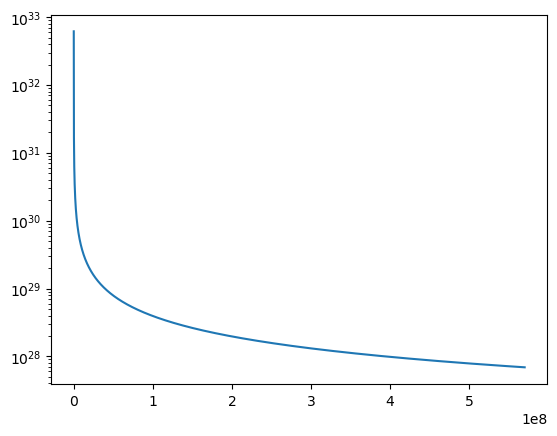

In [4]:
dist_E_M_2= 1.5*3.8*10**8
x = np.linspace(RE, dist_E_M_2, 10000)
y = abs(GP(ME, 0, 0, x, 0))

fig, ax = plt.subplots()
ax.semilogy(x,y)

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

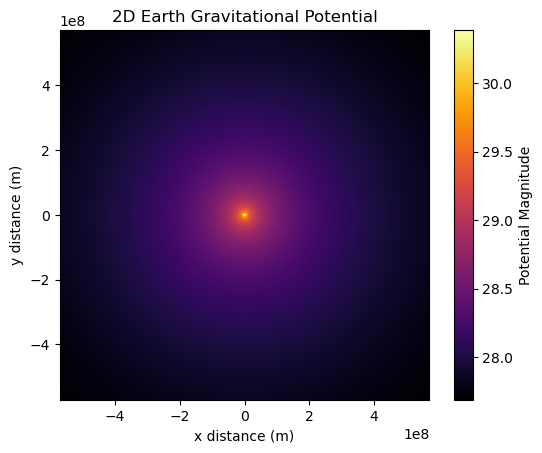

In [5]:
x_range = np.linspace(-dist_E_M_2, dist_E_M_2, 500)
y_range = np.linspace(-dist_E_M_2, dist_E_M_2, 500)
X, Y = np.meshgrid(x_range, y_range)
phi_val = np.abs(GP(ME, 0, 0, X, Y))
phi = np.log10(phi_val)

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.set_title("2D Earth Gravitational Potential")
ax.set_xlabel("x distance (m)")
ax.set_ylabel("y distance (m)")
mesh = ax.pcolormesh(x_range, y_range, phi, cmap='inferno')

cbar = fig.colorbar(mesh)
cbar.set_label("Potential Magnitude")

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

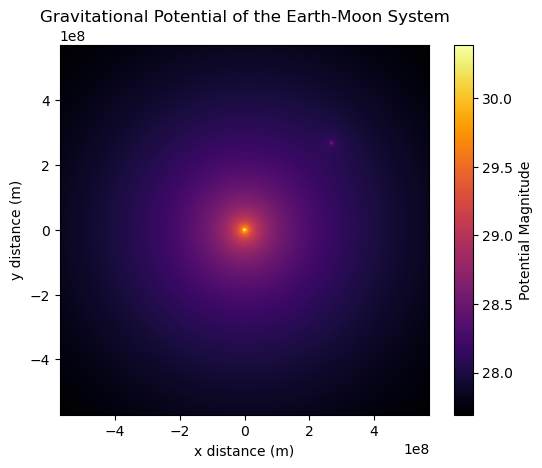

In [6]:
xM, yM = DEM / np.sqrt(2), DEM / np.sqrt(2)
x_range = np.linspace(-dist_E_M_2, dist_E_M_2, 500)
y_range = np.linspace(-dist_E_M_2, dist_E_M_2, 500)
X, Y = np.meshgrid(x_range, y_range)

phi_E = GP(ME, 0, 0, X, Y)
phi_M = GP(MM, xM, yM, X, Y)
z = np.log10(np.abs(phi_E+phi_M))
fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.set_title("Gravitational Potential of the Earth-Moon System")
ax.set_xlabel("x distance (m)")
ax.set_ylabel("y distance (m)")
mesh = ax.pcolormesh(x_range, y_range, z, cmap='inferno')

cbar = fig.colorbar(mesh)
cbar.set_label("Potential Magnitude")


2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

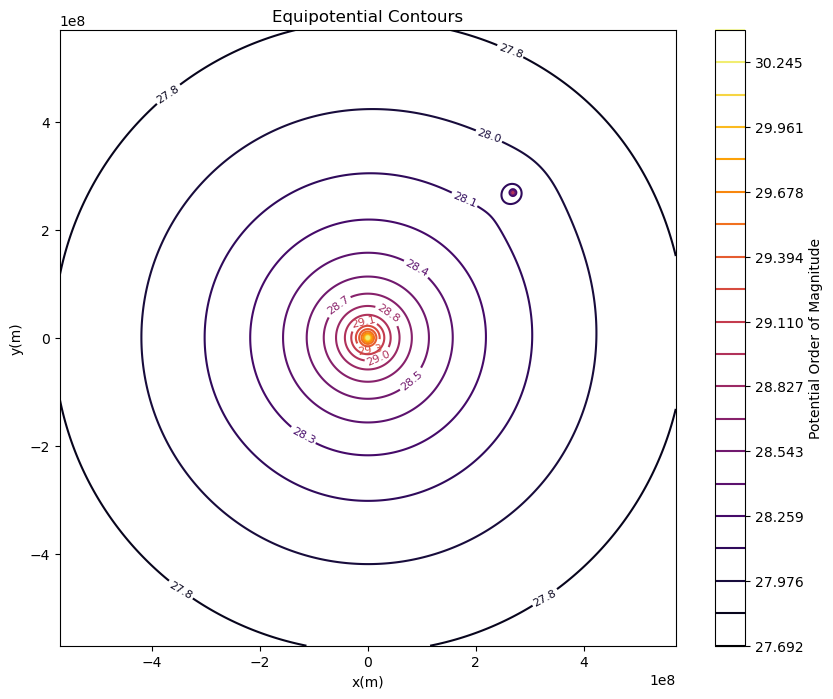

In [7]:
z = np.log10(np.abs(phi_E+phi_M))
levels = np.linspace(z.min(), z.max(), 20)

fig, ax = plt.subplots(figsize=(10, 8))
cntr = ax.contour(X, Y, z, levels=levels, cmap='inferno')

ax.clabel(cntr, inline=True, fontsize=8, fmt='%.1f')
ax.set_aspect('equal')
ax.set_title("Equipotential Contours")
ax.set_xlabel("x(m)")
ax.set_ylabel("y(m)")

cbar = fig.colorbar(cntr)
cbar.set_label("Potential Order of Magnitude")

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def GF(M1:float, m2:float, x1:float, y1:float, x2:float, y2:float) -> float:
    """
    Calculate the Gravitational Force that M1 exerts on m2.
    Args:
    M1 = mass 1
    m2 = mass 2
    x1, y2 = M1's position
    x2, y2 = m2's position
    Returns:
        fx: Force component in the x-direction.
        fy: Force component in the y-direction.

    Raises:
        ValueError: Singularity.
        TypeError: If inputs are not number values.
    """
    for name, val in {"M1": M1, "m2": m2, "x1": x1, "y1": y1, "x2": x2, "y2": y2}.items():
        if not isinstance(val, (int, float, np.ndarray, np.number)):
            raise TypeError(f"Argument '{name}' must be numeric, got {type(val).__name__}")
    if np.any(np.less(M1, 0)) or np.any(np.less(m2, 0)):
         raise ValueError("Error. Must be non-negative masses.")
    dx: float = x2 - x1
    dy: float = y2 - y1
    dist_sq: float = dx**2 + dy**2
    
    if isinstance(dist_sq, np.ndarray):
        if np.any(dist_sq == 0):
            dist_sq = np.where(dist_sq == 0, np.inf, dist_sq)
    else:
        if dist_sq == 0:
            raise ValueError("Singularity. Distance is zero. Please fix.")
    D: float = 1.0/(dist_sq**1.5)
    z: float = -G *M1*m2*D

    fx: float = z*dx
    fy: float = z*dy

    assert isinstance(fx, (float, np.ndarray, np.number)) and isinstance(fy, (float, np.ndarray, np.number))

    return fx, fy

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

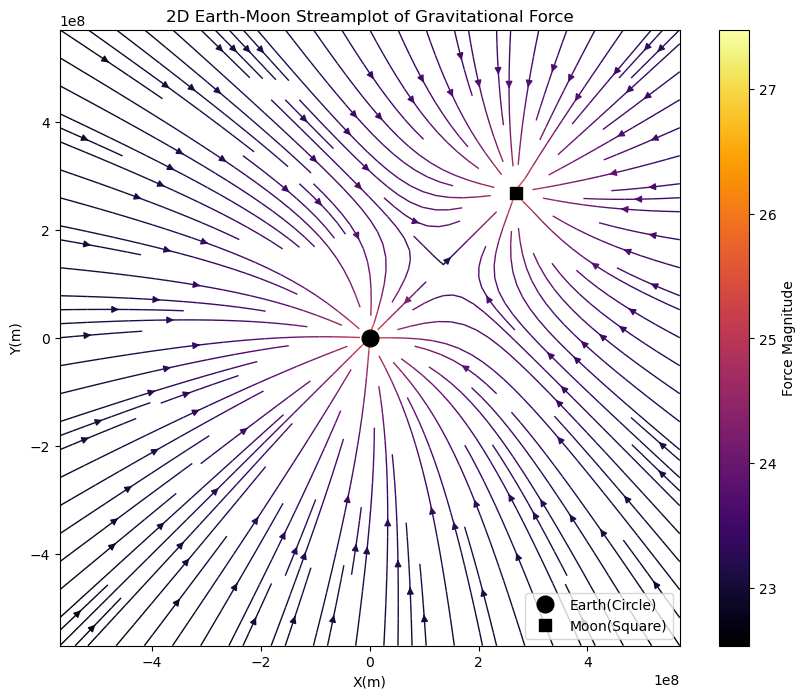

In [9]:
x_range = np.linspace(-dist_E_M_2, dist_E_M_2, 100)
y_range = np.linspace(-dist_E_M_2, dist_E_M_2, 100)
X, Y = np.meshgrid(x_range, y_range)

fxE, fyE = GF(ME, MA, 0, 0, X, Y)
fxM, fyM = GF(ME, MA, xM, yM, X, Y)
fx_total = fxE + fxM
fy_total = fyE + fyM
mag = np.sqrt(fx_total**2 + fy_total**2)
log_mag = np.log10(mag)

fig, ax = plt.subplots(figsize=(10, 8))
stream = ax.streamplot(X, Y, fx_total, fy_total, color=log_mag, cmap='inferno', linewidth=1, density=1.5)

ax.plot(0, 0, 'ko', markersize=12, label='Earth(Circle)')
ax.plot(xM, yM, 'ks', markersize=8, label='Moon(Square)')
ax.set_title("2D Earth-Moon Streamplot of Gravitational Force")
ax.set_xlabel("X(m)")
ax.set_ylabel("Y(m)")
ax.legend()

cbar = fig.colorbar(stream.lines, ax=ax)
cbar.set_label("Force Magnitude")

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

### Derivation of the Balance Point

$$G \frac{M_E m}{r^2} = G \frac{M_M m}{(d_{EM} - r)^2}$$

**Step 1**
$$\frac{M_E}{r^2} = \frac{M_M}{(d_{EM} - r)^2}$$

**Step 2**
$$\frac{(d_{EM} - r)^2}{r^2} = \frac{M_M}{M_E}$$

**Step 3**
$$\frac{d_{EM} - r}{r} = \sqrt{\frac{M_M}{M_E}}$$

**Step 4**
$$\frac{d_{EM}}{r} - 1 = \sqrt{\frac{M_M}{M_E}}$$

**Step 5**
$$\frac{d_{EM}}{r} = 1 + \sqrt{\frac{M_M}{M_E}}$$

**Step 6**
$$r = \frac{d_{EM}}{1 + \sqrt{\frac{M_M}{M_E}}}$$

And your updated plot, including the balance point, goes in the cell below.

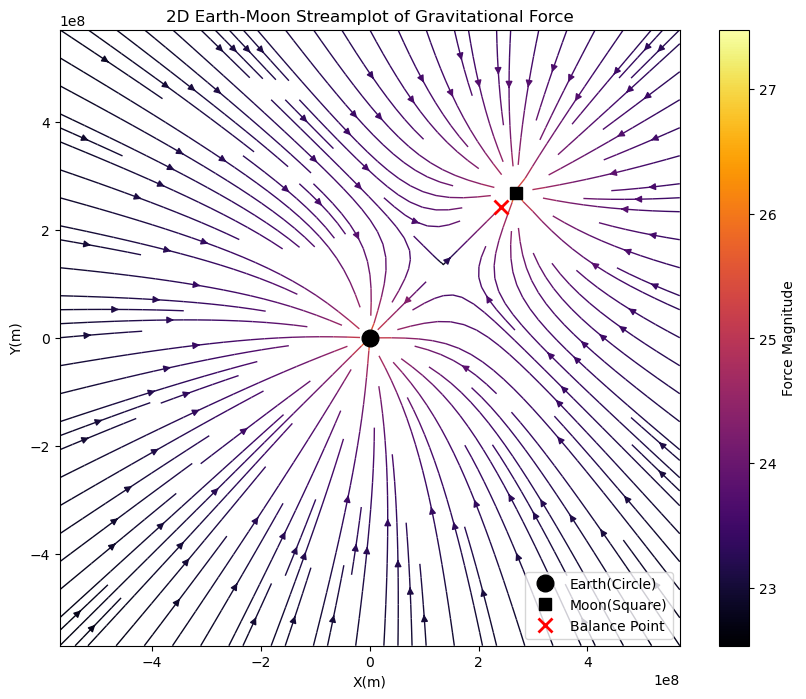

In [10]:
r = DEM / (1+np.sqrt(MM/ME))
x = r/np.sqrt(2)
y = r/np.sqrt(2)
xM, yM = DEM/np.sqrt(2), DEM/np.sqrt(2)
x_range = np.linspace(-dist_E_M_2, dist_E_M_2, 100)
y_range = np.linspace(-dist_E_M_2, dist_E_M_2, 100)
X, Y = np.meshgrid(x_range, y_range)

fxE, fyE = GF(ME, MA, 0, 0, X, Y)
fxM, fyM = GF(ME, MA, xM, yM, X, Y)
fx_total = fxE + fxM
fy_total = fyE + fyM
mag = np.sqrt(fx_total**2 + fy_total**2)
log_mag = np.log10(mag)

fig, ax = plt.subplots(figsize=(10, 8))
stream = ax.streamplot(X, Y, fx_total, fy_total, color=log_mag, cmap='inferno', linewidth=1, density=1.5)

ax.plot(0, 0, 'ko', markersize=12, label='Earth(Circle)')
ax.plot(xM, yM, 'ks', markersize=8, label='Moon(Square)')
ax.plot(x, y, 'rx', markersize=10, mew=2, label='Balance Point')
ax.set_title("2D Earth-Moon Streamplot of Gravitational Force")
ax.set_xlabel("X(m)")
ax.set_ylabel("Y(m)")
ax.legend()

cbar = fig.colorbar(stream.lines, ax=ax)
cbar.set_label("Force Magnitude")

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

It is closer to the moon. It is right next to the moon where as it is about (3,3) roughly away from the Earth. This is because Earth is much larger than the moon. This means it needs to be further so the force from the earth is balanced.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
T = (WM_S1C-DM_S1C)/BR
print(T)

157.69230769230768


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def Find_delta_v(t, WM_S1C, DM_S1C, BR, EV, g):
    """
    Find the change in velocity.

    Args:
        t (float): Time since ignition (s).
        WM_S1C (float): Initial "wet" mass (kg).
        DM_S1C (float): Final "dry" mass (kg).
        BR (float): Fuel burn rate (kg/s).
        EV (float): Fuel exhaust velocity (m/s).
        g (float): Gravitational acceleration (m/s^2).
    Returns:
        float: The change in velocity at t.
    Raises:
        TypeError: If any input is not an int or float.
        ValueError: If time t is negative or exceeds burnout time.
    """
    inputs = [t, WM_S1C, DM_S1C, BR, EV, g]
    if not all(isinstance(i, (int, float)) for i in inputs):
        raise TypeError("All arguments must be numeric (int or float). Try again.")

    T = (WM_S1C-DM_S1C)/BR
    if t < 0:
        raise ValueError("Time cannot be negative. Change time.")
    if t > T:
        raise ValueError(f"Burnout reached at T={T:.2f}s. Input t={t}s is invalid.")
    mt = WM_S1C - (BR*t)
    delta_v = EV*np.log(WM_S1C/mt)-(g*t)
    return delta_v

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
def altitude(WM_S1C, DM_S1C, BR, EV, g):
    """
    Finds altitude at burnout using numerical integration.
    """
    T = (WM_S1C - DM_S1C) / BR
    integrand = lambda t: Find_delta_v(t, WM_S1C, DM_S1C, BR, EV, g)
    altitude_h, error = quad(integrand, 0, T)
    return altitude_h
alt = altitude(WM_S1C, DM_S1C, BR, EV, g)
print(f"Burnout Altitude: {alt:.2f} m")

Burnout Altitude: 74093.98 m


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

The time was found to be an underestimate. This is because the rocket was not at full thrust the entie time so it took some time speed up resulting in it taking more time to go to its altitude. The altitude is overestimated because drag was not considered so we assumed it went farther than it really did. Also the exhaust velocity is not constant which means we assumed it was faster than it was really.